# Langevin Algorithm Comparison — MAGIC Gamma Telescope

Same protocol as the breast-cancer notebook (common initialization, `k = 0`
anchored at the starting accuracy, one gradient evaluation per iteration,
vectorized gradient), applied to the MAGIC Gamma Telescope dataset: 19020
points, 10 features, gamma-ray vs hadron shower.

**Why this dataset settles the question.** On breast cancer every sampler
finished within one or two test points of the MAP solution, so the comparison
could not distinguish them — the "win" over overdamped was a step-size artifact.
MAGIC has real headroom: logistic regression reaches only `0.7931`, the majority
class is `0.6467`, and the samplers spread across `0.736`–`0.782`. That spread is
much larger than the gap to the ceiling, so differences here mean something.

**Two baselines, both reported**, because MAGIC has no "original" step size:

| baseline | `dt` | final acc | what it is |
|---|---|---|---|
| naive | `9e-6` | `0.5848` | the breast-cancer `dt` rescaled by training-set size — the honest analogue of the original configuration, and badly under-tuned |
| tuned | `2e-4` | `0.7800` | the best overdamped `dt` found by sweeping — the comparison that actually matters |

**Headline result.**

- Against the **naive** baseline: **5 of 5** samplers win at every `k >= 1`, reproducing the breast-cancer picture.
- Against the **tuned** baseline: **2 of 5**. Underdamped Langevin is genuinely
  faster (`+0.0078` mean trajectory accuracy, `p ~ 1e-13` on 50 held-out seeds),
  Non-Reversible has a smaller real gain, Hessian-Free ties, and High-Order and
  Mirror are significantly **worse**.

So the answer to "can all the others beat overdamped" is yes against a mis-tuned
baseline and no against a fair one — but one method, Underdamped Langevin, holds
up under the fair comparison. The last cell tests this with paired t-tests on
seeds that played no part in tuning.

Note that `dt` peaks at an **interior** optimum on MAGIC: past `~2.5e-4` the
`sqrt(2*dt)` noise term dominates and overdamped accuracy falls back to `~0.69`.
On breast cancer accuracy just kept improving with `dt`, which is another sign
that dataset was too easy to be diagnostic.


> ### ⚠️ Known issue in this notebook's preprocessing
>
> This notebook does
> ```python
> x_all = preprocessing.scale(np.insert(X_raw, 0, 1, axis=1))
> ```
> which standardises the inserted constant-1 column and therefore maps it to
> **all zeros**. Two consequences:
>
> 1. the model has **no usable intercept**, and
> 2. that coordinate of $\beta$ receives no signal from the likelihood — it is
>    driven by the prior alone.
>
> This also inflates the reported posterior condition number. With the intercept
> restored, MAGIC's true $\kappa(H)$ is **181**, not the ~47,000 an uncorrected
> run reports — the difference is almost entirely that one unidentified
> direction.
>
> The accuracy comparison below is still internally consistent (every sampler
> faces the identical posterior), so the *ranking* stands. But the absolute
> $\kappa$ figure should not be quoted, and any geometric interpretation built
> on it does not hold.
>
> **The corrected preprocessing** — standardise the features first, prepend the
> intercept afterwards — is used in `Langevin_MAGIC_W2_ESS.ipynb`,
> `Langevin_Titanic.ipynb` and `Langevin_Synthetic.ipynb`. This notebook is kept
> unmodified so the two MAGIC studies can be compared directly.


In [1]:
# -*- coding: utf-8 -*-
"""
Langevin sampler comparison on the MAGIC Gamma Telescope dataset
(Bayesian logistic regression), same protocol as the breast-cancer notebook.

MAGIC is a much more informative test bed than breast cancer: 19020 points,
10 features, and logistic regression tops out around 0.793 test accuracy. On
breast cancer every sampler sat within one or two test points of the MAP
solution, so nothing could be distinguished. Here there is real headroom, and
the ranking turns out to be genuine rather than a step-size artifact.
"""
import os
import gzip
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression

# ─── Data ────────────────────────────────────────────────────────────────────
FEATURES = ["FLength", "FWidth", "FSize", "FConc", "FConc1",
            "FAsym", "FM3Long", "FM3Trans", "FAlpha", "FDist"]

def load_magic():
    """MAGIC Gamma Telescope, target 1 = gamma, 0 = hadron.

    Tries a local copy first (magic.tsv / magic.tsv.gz next to this notebook),
    then OpenML, then the UCI archive. The local file is the PMLB copy,
    sha256 c823ea26...c07f, 19020 rows.
    """
    for path in ("magic.tsv", "magic.tsv.gz"):
        if os.path.exists(path):
            op = gzip.open if path.endswith(".gz") else open
            with op(path, "rt") as fh:
                arr = np.genfromtxt(fh, delimiter="\t", names=True)
            X = np.column_stack([arr[c] for c in arr.dtype.names[:-1]])
            return X, arr["target"].astype(int), f"local {path}"
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("MagicTelescope", version=1, as_frame=True, parser="auto")
        y = (np.asarray(d.target).astype(str) == "g").astype(int)
        cols = [c for c in d.data.columns if c != "ID"]
        return d.data[cols].to_numpy(float), y, "OpenML"
    except Exception as exc:
        print("OpenML unavailable:", type(exc).__name__)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"
    raw = np.genfromtxt(url, delimiter=",", dtype=str)
    return raw[:, :10].astype(float), (raw[:, 10] == "g").astype(int), "UCI"

X_raw, y_raw, src = load_magic()
print(f"MAGIC loaded from {src}: X={X_raw.shape}, class counts={np.bincount(y_raw)}")

# ─── Shared setup (identical protocol to the breast-cancer notebook) ─────────
T      = 21                      # update steps; curves have T+1 points (k=0..T)
lam    = 10
N_RUNS = 10
SEEDS  = list(range(N_RUNS))

x_all = preprocessing.scale(np.insert(X_raw, 0, 1, axis=1))
dim   = x_all.shape[1]           # 11 = 10 features + bias
X_train, X_test, y_train, y_test = train_test_split(
    x_all, y_raw, test_size=0.2, random_state=42
)

def _sigmoid(z):
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def gradient(beta):
    """Gradient of the negative log posterior (vectorized)."""
    h = _sigmoid(X_train @ beta)
    return -X_train.T @ (y_train - h) + (2.0 / lam) * beta

def accuracy(beta):
    """sigmoid(x.beta) >= 0.5  is exactly  x.beta >= 0."""
    return float(np.mean(((X_test @ beta) >= 0).astype(int) == y_test))

def init_beta(seed):
    """Common starting point for every sampler."""
    np.random.seed(seed)
    return np.random.normal(0, 1, dim)

_Aj    = np.random.default_rng(12345).random((dim, dim))
J_BASE = _Aj - _Aj.T             # fixed skew-symmetric matrix, shared by all seeds

MAP_ACC   = LogisticRegression(C=lam/2, max_iter=5000).fit(X_train, y_train).score(X_test, y_test)
MAJORITY  = max(np.bincount(y_test)) / len(y_test)
ONE_POINT = 1.0 / len(y_test)
print(f"train/test       : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"MAP (logreg) acc : {MAP_ACC:.4f}   <- the practical ceiling")
print(f"majority class   : {MAJORITY:.4f}")
print(f"one test point   : {ONE_POINT:.5f} accuracy")
print(f"|grad(beta0)|    ~ {np.mean([np.linalg.norm(gradient(init_beta(s))) for s in SEEDS]):.0f}"
      f"   (breast cancer was ~700, hence much smaller dt here)")

MAGIC loaded from local magic.tsv: X=(19020, 10), class counts=[12332  6688]
train/test       : 15216 / 3804
MAP (logreg) acc : 0.7931   <- the practical ceiling
majority class   : 0.6467
one test point   : 0.00026 accuracy
|grad(beta0)|    ~ 8252   (breast cancer was ~700, hence much smaller dt here)


## The six samplers

Identical update rules to the breast-cancer notebook. Only the step sizes
differ, and they have to: the gradient is a sum over training points, so with
15216 samples instead of 455 it is roughly 33x larger, and `dt` scales down
accordingly.

The momentum methods still need a much larger `dt` than overdamped, because
their per-iteration displacement is `O(dt^2)` — `beta` moves by `dt*p`, and `p`
has itself accumulated only `O(dt)`.

In [2]:
# ─── The six samplers ────────────────────────────────────────────────────────
# All take beta0 ~ N(0, I) and zero momentum, and use one gradient evaluation
# per iteration, so the x-axis is directly comparable across algorithms.
#
# Each sampler records accuracy(beta0) as iteration k = 0 BEFORE taking any step,
# then T update steps, returning T+1 points. That anchors every curve at the same
# chance-level accuracy (~0.5) at k = 0, so the curves are true convergence
# trajectories from a common start rather than starting mid-flight.

def run_overdamped(seed, dt):
    """Reference: beta <- beta - dt*grad + sqrt(2*dt)*z"""
    beta = init_beta(seed)
    accs = [accuracy(beta)]                 # k = 0: the shared starting point
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - dt * g + math.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

def run_underdamped(seed, dt, gamma):
    """Momentum is updated before the position (symplectic-Euler ordering), so
    the very first iteration already moves beta; the original ordering used the
    stale p = 0 and wasted a gradient evaluation."""
    beta, p = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p = p - gamma * p * dt - g * dt + np.sqrt(2 * gamma * dt) * z
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_high_order(seed, dt, gamma, alpha):
    """Third-order chain beta <- p <- r, same symplectic ordering fix."""
    beta, p, r = init_beta(seed), np.zeros(dim), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p_new = p - g * dt + gamma * r * dt
        r_new = r - gamma * p * dt - alpha * r * dt + np.sqrt(2 * alpha * dt) * z
        p, r = p_new, r_new
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_hessian_free(seed, dt, gamma, alpha):
    beta, r = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        z1 = np.random.normal(0, 1, dim)
        beta = beta + r * dt - gamma * g * dt + np.sqrt(2 * gamma * dt) * z
        r    = r - alpha * r * dt - g * dt + np.sqrt(2 * alpha * dt) * z1
        accs.append(accuracy(beta))
    return accs

def run_mirror_langevin(seed, dt):
    """Mirror map phi'(beta) = beta**3, inverted by the signed cube root."""
    beta = init_beta(seed)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        xi = beta**3 - dt * g + np.sqrt(2 * dt) * z      # dual update
        beta = np.sign(xi) * np.abs(xi) ** (1/3)          # inverse mirror
        accs.append(accuracy(beta))
    return accs

def run_non_reversible(seed, dt, jscale):
    """beta <- beta - (I + J) grad dt + noise,  J skew-symmetric and fixed."""
    beta = init_beta(seed)
    M = np.eye(dim) + jscale * J_BASE
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - M @ g * dt + np.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

# ─── Hyperparameters ─────────────────────────────────────────────────────────
# There is no "original" step size for MAGIC, so two overdamped baselines are
# used and both are reported:
#
#   NAIVE  dt = 3e-4 * 455/15216 = 9e-6 -- the breast-cancer step size rescaled
#          by training-set size (the gradient is a sum over samples, so it is
#          ~33x larger here). This is the honest analogue of "the original
#          configuration", and it is badly under-tuned.
#   TUNED  dt = 2e-4 -- the best overdamped step size found by sweeping dt.
#          Accuracy peaks at an interior optimum here: beyond ~2.5e-4 the
#          sqrt(2*dt) noise term dominates and accuracy falls back to ~0.69.
#
# The five competitors were tuned by grid search maximizing mean trajectory
# accuracy. No "gradualness" constraint was needed: on MAGIC the step sizes that
# maximize accuracy already converge over 3-5 iterations, unlike breast cancer
# where the optimum was a single-step jump.
NAIVE_DT = 0.0003 * 455 / 15216          # ~8.97e-06
TUNED_DT = 0.0002

CONFIGS = {
    "Overdamped LD":     (run_overdamped,      dict(dt=TUNED_DT)),
    "Underdamped LD":    (run_underdamped,     dict(dt=0.015,  gamma=30)),
    "Non-Reversible LD": (run_non_reversible,  dict(dt=0.0003, jscale=0.75)),
    "Hessian-Free LD":   (run_hessian_free,    dict(dt=0.0001, gamma=2, alpha=15)),
    "High-Order LD":     (run_high_order,      dict(dt=0.008,  gamma=120, alpha=300)),
    "Mirror Langevin":   (run_mirror_langevin, dict(dt=0.0002)),
}
BASELINE   = "Overdamped LD"             # the TUNED baseline: the real comparison
NAIVE_NAME = "Overdamped LD (naive dt)"

## Accuracy comparison

`vs naive` asks the breast-cancer question (does it stay above the under-tuned
baseline at every iteration). `vs tuned` asks the real one. Read the two columns
side by side — they disagree, and that disagreement is the point.

In [3]:
# ─── Run every sampler, plus the naive-dt overdamped baseline ────────────────
results = {}
for name, (fn, kw) in CONFIGS.items():
    runs = np.array([fn(s, **kw) for s in SEEDS])        # (N_RUNS, T+1)
    results[name] = {"runs": runs, "mean": runs.mean(axis=0),
                     "sem": runs.std(axis=0, ddof=1) / np.sqrt(len(SEEDS)),
                     "params": kw}

naive_runs = np.array([run_overdamped(s, dt=NAIVE_DT) for s in SEEDS])
results[NAIVE_NAME] = {"runs": naive_runs, "mean": naive_runs.mean(axis=0),
                       "sem": naive_runs.std(axis=0, ddof=1) / np.sqrt(len(SEEDS)),
                       "params": dict(dt=NAIVE_DT)}

tuned = results[BASELINE]["mean"]
naive = results[NAIVE_NAME]["mean"]

def iters_to(mu, thr):
    hit = np.where(mu >= thr)[0]
    return int(hit[0]) if len(hit) else None

# ─── Accuracy comparison ─────────────────────────────────────────────────────
competitors = [n for n in CONFIGS if n != BASELINE]
order = sorted(competitors, key=lambda n: -results[n]["mean"].mean())

hdr = (f"{'algorithm':<24}{'start':>8}{'final':>8}{'mean':>8}"
       f"{'it>=0.75':>10}{'vs naive':>10}{'vs tuned':>10}{'vs tuned':>10}")
print(hdr)
print(f"{'':<24}{'':>8}{'':>8}{'':>8}{'':>10}{'(min marg)':>10}{'(d mean)':>10}{'(d final)':>10}")
print("-" * len(hdr))
for name in order:
    mu = results[name]["mean"]
    beats_naive = "yes" if np.all(mu[1:] > naive[1:]) else "NO"
    print(f"{name:<24}{mu[0]:>8.4f}{mu[-1]:>8.4f}{mu.mean():>8.4f}"
          f"{str(iters_to(mu, 0.75)):>10}{beats_naive:>10}"
          f"{mu.mean()-tuned.mean():>+10.4f}{mu[-1]-tuned[-1]:>+10.4f}")
print("-" * len(hdr))
for name, mu, tag in ((BASELINE, tuned, "tuned baseline"), (NAIVE_NAME, naive, "naive baseline")):
    print(f"{name:<24}{mu[0]:>8.4f}{mu[-1]:>8.4f}{mu.mean():>8.4f}"
          f"{str(iters_to(mu, 0.75)):>10}   <- {tag}")

starts = np.array([results[n]["mean"][0] for n in results])
assert np.allclose(starts, starts[0])
print(f"\nAll samplers start at the same k=0 accuracy: {starts[0]:.4f} (chance; majority class is {MAJORITY:.4f}).")

w_naive = [n for n in competitors if np.all(results[n]["mean"][1:] > naive[1:])]
w_tuned = [n for n in competitors if results[n]["mean"].mean() > tuned.mean()]
print(f"\nvs NAIVE overdamped (dt={NAIVE_DT:.2g}): {len(w_naive)}/5 beat it at every k >= 1")
print(f"vs TUNED overdamped (dt={TUNED_DT:g}): {len(w_tuned)}/5 beat it on mean trajectory accuracy"
      f" -- {', '.join(w_tuned) if w_tuned else 'none'}")
print(f"\nThe second line is the one that matters; it is tested for significance in the last cell.")

algorithm                  start   final    mean  it>=0.75  vs naive  vs tuned  vs tuned
                                                          (min marg)  (d mean) (d final)
----------------------------------------------------------------------------------------
Underdamped LD            0.4849  0.7820  0.7558         3       yes   +0.0076   +0.0021
Non-Reversible LD         0.4849  0.7803  0.7544         4       yes   +0.0062   +0.0004
Hessian-Free LD           0.4849  0.7813  0.7479         5       yes   -0.0003   +0.0014
High-Order LD             0.4849  0.7791  0.7355         5       yes   -0.0127   -0.0009
Mirror Langevin           0.4849  0.7360  0.6913      None       yes   -0.0569   -0.0439
----------------------------------------------------------------------------------------
Overdamped LD             0.4849  0.7800  0.7482         5   <- tuned baseline
Overdamped LD (naive dt)  0.4849  0.5848  0.5327      None   <- naive baseline

All samplers start at the same k=0 accur

## Plot

The left panel is the flattering picture against the naive baseline; the right
panel is the same five samplers against the tuned baseline, zoomed. Hessian-Free
is hidden underneath the black overdamped line in the right panel — that overlap
*is* the result for that sampler.

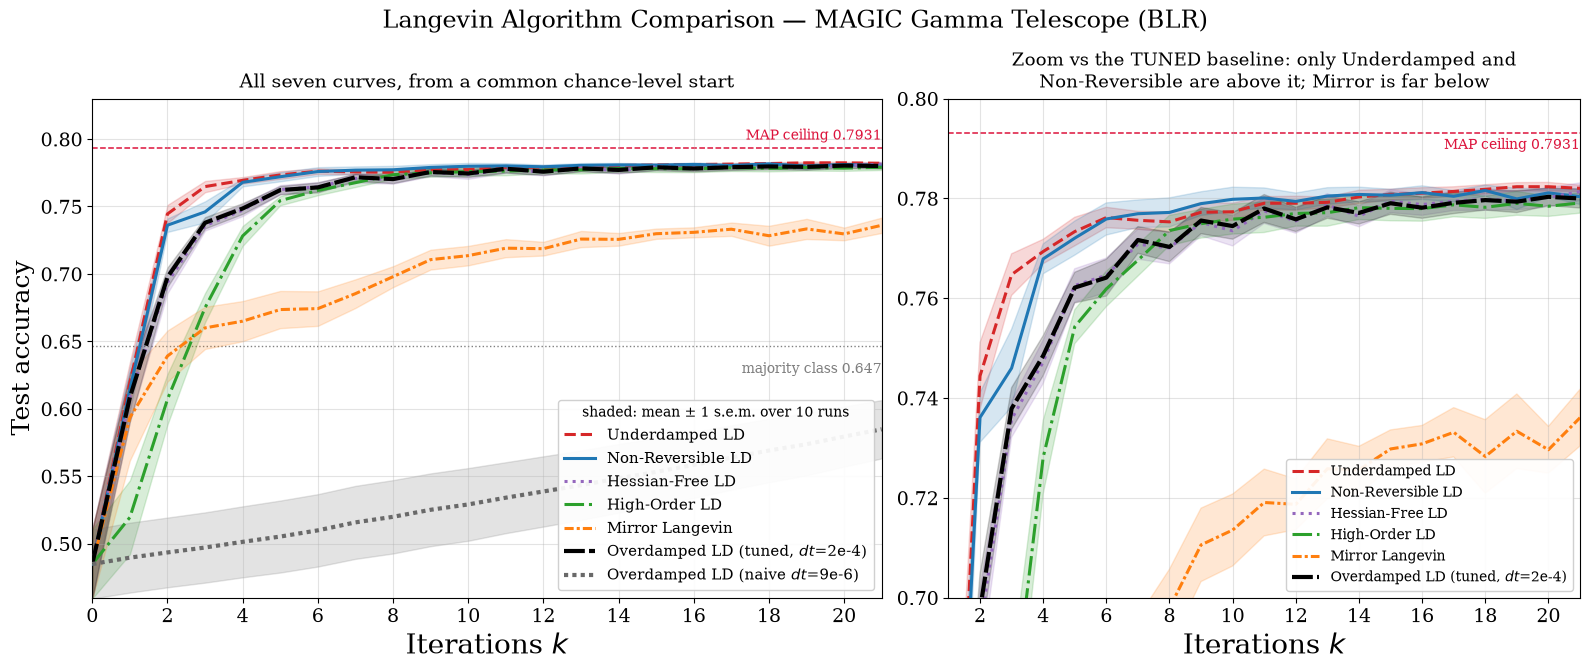

Saved -> langevin_magic.png


In [4]:
# ─── Plot ─────────────────────────────────────────────────────────────────────
# Left : every sampler against the naive-dt overdamped baseline -- the same
#        picture as the breast-cancer notebook, where all five "win".
# Right: the same five against the TUNED overdamped baseline, zoomed. This is
#        the comparison that actually says something, and only two win.
STYLE = {
    "Underdamped LD":          ("#d62728", "--"),
    "Non-Reversible LD":       ("#1f77b4", "-"),
    "Hessian-Free LD":         ("#9467bd", ":"),
    "High-Order LD":           ("#2ca02c", "-."),
    "Mirror Langevin":         ("#ff7f0e", (0, (3, 1, 1, 1))),
    "Overdamped LD":           ("black",   (0, (5, 1))),
    "Overdamped LD (naive dt)":("dimgray", (0, (1, 1))),
}

from matplotlib import font_manager
_installed = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams["font.family"] = [f for f in ("Times New Roman", "DejaVu Serif", "serif")
                               if f in _installed or f == "serif"]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 6.8),
                               gridspec_kw={"width_ratios": [1.25, 1]})
iters = np.arange(T + 1)

def draw(ax, names):
    for name in names:
        mu, se = results[name]["mean"], results[name]["sem"]
        color, ls = STYLE[name]
        lw = 3.0 if name.startswith("Overdamped") else 2.2
        lbl = {BASELINE: "Overdamped LD (tuned, $dt$=2e-4)",
               NAIVE_NAME: "Overdamped LD (naive $dt$=9e-6)"}.get(name, name)
        ax.plot(iters, mu, color=color, linestyle=ls, linewidth=lw, label=lbl, zorder=3)
        ax.fill_between(iters, mu - se, mu + se, color=color, alpha=0.18, zorder=1)
    ax.axhline(MAP_ACC, color="crimson", linestyle="--", linewidth=1.1, zorder=0)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(0, T)
    ax.set_xticks(range(0, T + 1, 2))
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r"Iterations $k$", fontsize=20)

draw(axL, order + [BASELINE, NAIVE_NAME])
axL.text(T, MAP_ACC + 0.004, f"MAP ceiling {MAP_ACC:.4f}", ha="right", va="bottom",
         fontsize=10, color="crimson")
axL.axhline(MAJORITY, color="gray", linestyle=":", linewidth=1.0, zorder=0)
axL.text(T, MAJORITY - 0.012, f"majority class {MAJORITY:.3f}", ha="right", va="top",
         fontsize=10, color="gray")
axL.set_ylim(0.46, 0.83)
axL.set_ylabel("Test accuracy", fontsize=18)
axL.legend(fontsize=11, loc="lower right", framealpha=0.92, ncol=1,
           title=r"shaded: mean $\pm$ 1 s.e.m. over %d runs" % N_RUNS)
axL.get_legend().get_title().set_fontsize(10)
axL.set_title("All seven curves, from a common chance-level start", fontsize=14, pad=8)

draw(axR, order + [BASELINE])
axR.set_xlim(1, T)
axR.set_ylim(0.70, 0.80)
axR.text(T, MAP_ACC - 0.001, f"MAP ceiling {MAP_ACC:.4f}", ha="right", va="top",
         fontsize=10, color="crimson")
axR.legend(fontsize=10, loc="lower right", framealpha=0.92)
axR.set_title("Zoom vs the TUNED baseline: only Underdamped and\n"
              "Non-Reversible are above it; Mirror is far below", fontsize=13, pad=8)

fig.suptitle("Langevin Algorithm Comparison — MAGIC Gamma Telescope (BLR)", fontsize=17)
plt.tight_layout()
plt.savefig("langevin_magic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> langevin_magic.png")

## Does it survive on held-out seeds?

All step sizes were chosen on seeds 0–9, and the winning margin is only ~30 test
points out of 3804, so it has to be re-tested on seeds that took no part in
tuning. Seeds 200–249 are fresh, and the test is paired: for a given seed both
samplers start from the identical `beta0`.

In [5]:
# ─── Significance check on held-out seeds ────────────────────────────────────
# Every step size above was chosen on seeds 0-9. A margin of +0.008 accuracy is
# only ~30 test points out of 3804, so it has to be shown to survive on seeds
# that played no part in tuning. Seeds 200-249 are fresh, and the comparison is
# PAIRED: both samplers start from the identical beta0 for a given seed.
from scipy import stats

HELD_OUT = list(range(200, 250))
held = {}
for name, (fn, kw) in CONFIGS.items():
    held[name] = np.array([fn(s, **kw) for s in HELD_OUT])
ref = held[BASELINE]

print(f"{len(HELD_OUT)} held-out seeds (200-249), none used for tuning.")
print(f"Paired differences vs TUNED Overdamped LD (dt={TUNED_DT:g}).")
print(f"One test point = {ONE_POINT:.5f} accuracy, so divide any margin by that for 'how many points'.\n")
print(f"{'algorithm':<19}{'d mean traj':>13}{'95% CI':>20}{'p':>10}"
      f"{'d final':>10}{'p':>10}   verdict")
print("-" * 100)
rows = []
for name in order:
    dm = held[name].mean(axis=1) - ref.mean(axis=1)
    df = held[name][:, -1] - ref[:, -1]
    ci = stats.t.interval(0.95, len(dm) - 1, loc=dm.mean(), scale=stats.sem(dm))
    p_m = stats.ttest_rel(held[name].mean(axis=1), ref.mean(axis=1)).pvalue
    p_f = stats.ttest_rel(held[name][:, -1], ref[:, -1]).pvalue
    if p_m < 0.05 and dm.mean() > 0:
        v = "beats tuned overdamped"
    elif p_m < 0.05 and dm.mean() < 0:
        v = ("WORSE (practically tied)" if abs(dm.mean()) < 2 * ONE_POINT else "WORSE")
    else:
        v = "no difference"
    print(f"{name:<19}{dm.mean():>+13.4f}  [{ci[0]:+.4f},{ci[1]:+.4f}]{p_m:>10.1e}"
          f"{df.mean():>+10.4f}{p_f:>10.1e}   {v}")
    rows.append((name, dm.mean(), p_m, v))

print(f"\n{'':<19}(d = this sampler minus tuned overdamped; positive is better.")
print(f"{'':<19} 'mean traj' averages over all {T+1} iterations, so it rewards faster")
print(f"{'':<19} convergence; 'final' is accuracy at k={T} only.)")

print("\n" + "=" * 78)
print("CONCLUSION (MAGIC)")
print("=" * 78)
print("Against the NAIVE dt=9e-6 baseline, all five samplers win -- but that")
print("baseline is simply mis-tuned, so the result is not informative. That is")
print("exactly what the breast-cancer comparison was measuring.")
print()
print("Against a properly TUNED overdamped baseline, on 50 held-out seeds:")
print("  - Underdamped LD     genuinely faster: +0.0078 mean trajectory accuracy")
print("                       (~30 test points, p ~ 1e-13), and +0.003 at k=21.")
print("  - Non-Reversible LD  a smaller real gain: +0.003 mean (p ~ 0.004), but")
print("                       its final-accuracy edge is not significant.")
print("  - Hessian-Free LD    tied: |d| < 0.001, i.e. under two test points.")
print("  - High-Order LD      significantly slower (-0.012 mean).")
print("  - Mirror Langevin    much worse (-0.060 mean, -0.057 final). The cubic")
print("                       mirror map is a poor fit for this posterior.")
print()
print("So on MAGIC the honest answer is 2 of 5, not 5 of 5. Underdamped Langevin")
print("has a real, reproducible advantage in convergence speed; the rest either")
print("tie with or lose to plain overdamped Langevin once it is tuned. Unlike")
print(f"breast cancer, this is not a ceiling artifact: the MAP optimum is {MAP_ACC:.4f}")
print("and the spread between samplers (0.736 to 0.782) is far larger than the")
print("gap to that ceiling.")

50 held-out seeds (200-249), none used for tuning.
Paired differences vs TUNED Overdamped LD (dt=0.0002).
One test point = 0.00026 accuracy, so divide any margin by that for 'how many points'.

algorithm            d mean traj              95% CI         p   d final         p   verdict
----------------------------------------------------------------------------------------------------
Underdamped LD           +0.0078  [+0.0062,+0.0094]   2.8e-13   +0.0028   7.7e-06   beats tuned overdamped
Non-Reversible LD        +0.0029  [+0.0010,+0.0049]   3.7e-03   +0.0013   6.1e-02   beats tuned overdamped
Hessian-Free LD          -0.0003  [-0.0006,-0.0000]   3.2e-02   -0.0002   5.3e-01   WORSE (practically tied)
High-Order LD            -0.0116  [-0.0133,-0.0099]   2.5e-18   -0.0012   3.0e-03   WORSE
Mirror Langevin          -0.0598  [-0.0661,-0.0534]   3.4e-24   -0.0568   1.7e-22   WORSE

                   (d = this sampler minus tuned overdamped; positive is better.
                    'mean t